# Project - Predicting the direction of stock prices at the end of the trading session

## 1. Introduction
- Présentation du challenge
- Objectif
- Nature du problème : classification à 3 classes
- Métrique choisie / imposée

## 2. Imports and configuration
- Import des librairies
- Paramètres globaux
- Seed

In [17]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from scipy.stats import skew, kurtosis
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 3. Data loading
- Chargement de train et test
- Aperçu des données
- Vérification des colonnes
- Gestion de la target

In [18]:
X_train_raw = pd.read_csv("input_training.csv")
X_test_raw = pd.read_csv("input_test.csv")
y_train_raw = pd.read_csv("output_training_gmEd6Zt.csv")

In [19]:
train = X_train_raw.merge(y_train_raw, on="ID", how="inner")
test = X_test_raw.copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

display(train)
display(test)

Train shape: (843299, 57)
Test shape: (885799, 56)


,ID,day,equity,r0,r1,r2,r3,r4,r5,r6,...,r44,r45,r46,r47,r48,r49,r50,r51,r52,reod
0,0,249,1488,0.00,NaN,NaN,NaN,0.00,NaN,NaN,...,0.00,NaN,0.00,NaN,0.00,NaN,NaN,NaN,0.00,0
1,1,272,107,-9.76,0.00,-12.21,46.44,34.08,0.00,41.24,...,-16.92,-4.84,4.84,0.00,7.26,-9.68,-19.38,9.71,26.68,0
2,2,323,1063,49.85,0.00,0.00,-26.64,-23.66,-22.14,49.12,...,1.59,6.37,-49.32,-9.59,-6.40,22.41,-6.39,7.99,15.96,-1
3,3,302,513,0.00,NaN,0.00,0.00,0.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0
4,4,123,1465,-123.84,-115.18,-26.44,0.00,42.42,10.56,0.00,...,-21.44,-21.48,10.78,-21.55,-5.40,-10.81,5.41,-32.47,43.43,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
843294,843294,297,123,3.96,0.00,-70.34,74.24,-0.56,0.00,-23.63,...,1.71,0.00,-3.98,2.28,-21.62,-1.71,9.12,0.00,9.11,1
843295,843295,16,1501,0.00,-183.49,-13.19,46.24,0.00,-39.60,13.25,...,6.62,0.00,19.85,0.00,-26.42,6.62,0.00,0.00,-19.88,-1
843296,843296,166,1231,37.02,2.93,-3.67,16.89,-4.03,13.56,-4.39,...,-3.28,-1.46,-3.65,-1.10,-13.51,2.92,-6.21,9.69,-3.66,0
843297,843297,297,747,34.45,15.10,-35.61,19.25,-16.46,-26.12,20.68,...,-5.52,-6.90,9.67,1.38,6.90,-11.04,33.16,13.77,12.38,1


,ID,day,equity,r0,r1,r2,r3,r4,r5,r6,...,r43,r44,r45,r46,r47,r48,r49,r50,r51,r52
0,1000000,1000384,1000064,79.19,-26.37,-167.18,103.46,-102.27,-198.02,13.77,...,-116.69,29.82,-29.69,77.57,23.75,82.94,-17.63,17.60,5.87,0.00
1,1000001,1000148,1000841,-321.77,-178.53,107.97,27.29,-64.54,-73.78,9.93,...,-12.21,1.53,32.08,-33.50,-21.41,43.89,68.07,-23.20,-13.14,-82.95
2,1000002,1000441,1000380,-51.95,-19.58,-26.16,-26.28,-3.29,3.29,-46.11,...,13.56,-10.16,-40.68,13.61,3.40,6.80,10.20,0.00,-10.19,-6.80
3,1000003,1000059,1001843,-169.49,9.57,-76.48,28.90,0.00,-19.21,105.87,...,-9.72,-9.72,-9.73,-9.74,29.24,-29.18,34.15,14.58,-29.13,4.87
4,1000004,1000336,1001783,-46.19,32.17,-3.08,-32.06,11.75,27.81,-13.55,...,-3.68,-1.84,-1.23,1.23,5.53,-7.37,1.84,1.23,0.61,-4.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885794,1885794,1000125,1001131,0.00,67.87,-67.41,-18.15,12.99,-42.80,29.96,...,-1.27,5.09,-12.73,5.10,-8.91,-20.41,2.56,0.00,-7.67,6.40
885795,1885795,1000314,1000333,76.29,-65.02,2.73,-24.54,-17.78,13.70,-19.17,...,1.36,-1.36,-13.65,0.00,0.00,-4.10,-2.73,10.94,10.93,8.18
885796,1885796,1000247,1000348,-73.66,37.11,-7.92,-7.93,0.00,-18.49,-26.46,...,-7.97,10.63,5.31,-10.61,0.00,13.28,-5.31,6.64,7.96,5.30
885797,1885797,1000035,1000040,0.00,-102.74,NaN,NaN,NaN,NaN,NaN,...,0.00,NaN,0.00,NaN,0.00,0.00,NaN,0.00,NaN,NaN


### Interprétation des variables $r_0$ à $r_{52}$

Les variables $r_0$ à $r_{52}$ représentent les rendements intraday observés toutes les **5 minutes** au cours de la journée de trading.

Chaque variable correspond au rendement sur un intervalle de 5 minutes :
- $r_0$ correspond au rendement observé durant les 5 premières minutes,
- $r_1$ correspond aux 5 minutes suivantes,
- et ainsi de suite jusqu’à $r_{52}$.

Ces variables décrivent donc la **trajectoire intraday du prix d’une action** pendant la séance.

L’objectif du modèle est d’exploiter cette dynamique intraday afin de **prédire la direction du rendement à la fin de la séance de trading**, représentée par la variable cible $reod$.

### Dimensions du jeu de données

Le jeu de données d’entraînement contient **843\,299 observations et 57 variables**, tandis que le jeu de test contient **885\,799 observations et 56 variables**.

La différence entre les deux jeux provient de la présence de la variable cible $reod$, disponible uniquement dans les données d’entraînement.

Les datasets contiennent trois types de variables :

- **Variables d’identification**
  - $ID$ : identifiant unique de l’observation
  - $day$ : identifiant du jour de trading
  - $equity$ : identifiant de l’action

- **Variables explicatives**
  - $r_0$ à $r_{52}$ : rendements intraday observés toutes les 5 minutes

- **Variable cible**
  - $reod$ : direction du rendement en fin de séance, que le modèle doit prédire.

L’objectif de notre modèle de machine learning est d’apprendre des **patterns dans la trajectoire intraday des rendements** afin de prédire la direction finale du mouvement du prix.

In [20]:
print(train.columns.tolist())

['ID', 'day', 'equity', 'r0', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'r13', 'r14', 'r15', 'r16', 'r17', 'r18', 'r19', 'r20', 'r21', 'r22', 'r23', 'r24', 'r25', 'r26', 'r27', 'r28', 'r29', 'r30', 'r31', 'r32', 'r33', 'r34', 'r35', 'r36', 'r37', 'r38', 'r39', 'r40', 'r41', 'r42', 'r43', 'r44', 'r45', 'r46', 'r47', 'r48', 'r49', 'r50', 'r51', 'r52', 'reod']


In [21]:
return_cols = [col for col in train.columns if col.startswith("r") and col != "reod"]
return_cols = sorted(return_cols, key=lambda x: int(x[1:]))

print("Number of return columns:", len(return_cols))
print(return_cols[:5], "...", return_cols[-5:])


Number of return columns: 53
['r0', 'r1', 'r2', 'r3', 'r4'] ... ['r48', 'r49', 'r50', 'r51', 'r52']


In [31]:
TARGET = "reod"

y = train[TARGET].copy()
X_raw = train.drop(columns=[TARGET]).copy()
X_test_raw = test.copy()

print(y.value_counts(dropna=False).sort_index())

reod
-1    253639
 0    347465
 1    242195
Name: count, dtype: int64


In [32]:
class_counts = y.value_counts().sort_index()
class_percent = y.value_counts(normalize=True).sort_index() * 100

distribution = pd.DataFrame({"count": class_counts, "percentage": class_percent.round(2)})
display(distribution)

,count,percentage
reod,,
-1,253639,30.08
0,347465,41.20
1,242195,28.72


### Distribution de la variable cible

La variable cible $reod$ prend trois valeurs possibles : $-1$, $0$ et $1$, correspondant respectivement à une **baisse**, une **stabilité** ou une **hausse** du rendement en fin de séance.

La distribution observée dans les données d'entraînement est la suivante :

- Classe $-1$ : **30.08 \%**
- Classe $0$ : **41.20 \%**
- Classe $1$ : **28.72 \%**

On observe que la classe $0$ (absence de variation significative) est légèrement dominante, tandis que les classes $-1$ et $1$ sont relativement équilibrées.

Cette structure est cohérente avec les données financières : les variations modérées sont généralement plus fréquentes que les mouvements de marché plus marqués.

## 4. Exploratory Data Analysis
- Dimensions
- Missing values
- Distribution de la target
- Statistiques descriptives
- Visualisations simples des rendements intraday


In [33]:
print(train.isna().sum().sort_values(ascending=False).head(20))

r44    102595
r2     102470
r45    101842
r43    100894
r42    100777
r47    100517
r48    100084
r46     99986
r50     99645
r51     99354
r49     98510
r1      96815
r52     96784
r5      95458
r3      94169
r4      93730
r32     92840
r38     92469
r35     92205
r39     91983
dtype: int64


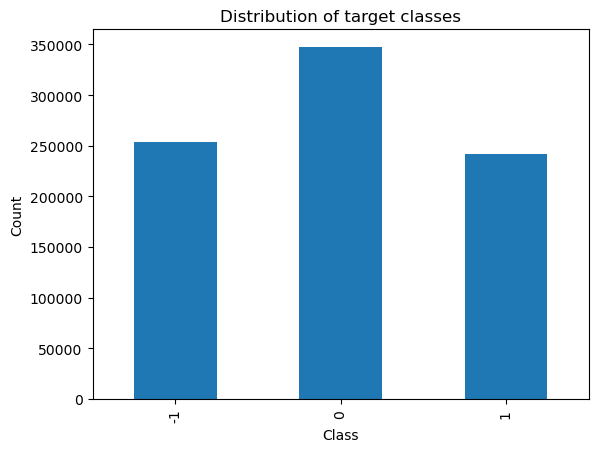

In [25]:
y.value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of target classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [34]:
train[return_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
r0,797476.0,1839.874545,609754.773379,-9967.67,-30.5800,0.0,21.34,4.310700e+08
r1,746484.0,193.534369,115327.121385,-9973.54,-21.1000,0.0,20.71,7.516000e+07
r2,740829.0,70.113991,55888.225790,-4823.74,-17.6000,0.0,16.51,4.789000e+07
r3,749130.0,19.564481,17850.550113,-1949.69,-17.4700,0.0,15.17,1.545000e+07
r4,749569.0,-0.215511,44.724646,-1390.13,-14.4100,0.0,14.23,2.327870e+03
r5,747841.0,0.283935,41.548517,-1632.29,-12.5600,0.0,13.27,2.396690e+03
r6,751778.0,-0.313301,40.706372,-1559.32,-13.6000,0.0,13.37,2.343750e+03
r7,757167.0,-1.195195,38.327389,-2066.67,-13.7600,0.0,11.44,2.733810e+03
r8,753221.0,-0.811229,36.044397,-1359.00,-12.6400,0.0,10.74,1.477440e+03
r9,753369.0,0.405408,34.341933,-1390.42,-10.3400,0.0,11.25,2.462310e+03


### Interprétation des variables $r_0$ à $r_{52}$

Les variables $r_0$ à $r_{52}$ représentent les rendements intraday observés toutes les **5 minutes** au cours de la journée de trading.

Chaque variable correspond au rendement sur un intervalle de 5 minutes :
- $r_0$ correspond au rendement observé durant les 5 premières minutes,
- $r_1$ correspond aux 5 minutes suivantes,
- et ainsi de suite jusqu’à $r_{52}$.

Ces variables décrivent donc la **trajectoire intraday du prix d’une action** pendant la séance.

L’objectif du modèle est d’exploiter cette dynamique intraday afin de **prédire la direction du rendement à la fin de la séance de trading**, représentée par la variable cible $reod$.

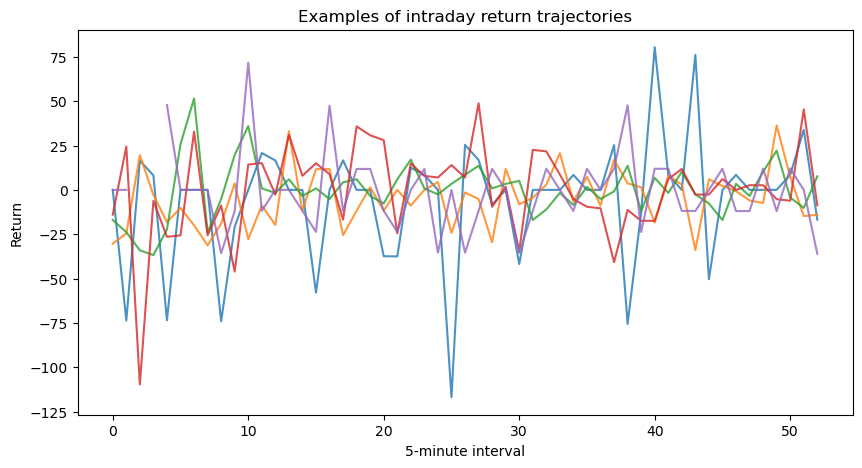

In [27]:
sample_idx = np.random.choice(train.index, size=min(5, len(train)), replace=False)

plt.figure(figsize=(10, 5))
for idx in sample_idx:
    plt.plot(range(len(return_cols)), train.loc[idx, return_cols].values, alpha=0.8)
plt.title("Examples of intraday return trajectories")
plt.xlabel("5-minute interval")
plt.ylabel("Return")
plt.show()


## 5. Feature engineering
- Construction des features à partir de r0 à r52
- Features de tendance, volatilité, extrêmes, momentum, forme de trajectoire
- Variables day / equity si utile
- Préparation finale de X_train / y_train / X_test

In [28]:
def longest_streak(arr, positive=True):
    best = 0
    cur = 0
    for x in arr:
        cond = x > 0 if positive else x < 0
        if cond:
            cur += 1
            best = max(best, cur)
        else:
            cur = 0
    return best

def safe_autocorr(x, lag=1):
    x = np.asarray(x)
    if len(x) <= lag or np.std(x) == 0:
        return 0.0
    return np.corrcoef(x[:-lag], x[lag:])[0, 1]

def compute_slope(arr):
    arr = np.asarray(arr)
    x = np.arange(len(arr))
    if np.std(arr) == 0:
        return 0.0
    slope = np.polyfit(x, arr, 1)[0]
    return slope

def build_features(df, return_cols):
    df = df.copy()
    R = df[return_cols].copy()
    
    feats = pd.DataFrame(index=df.index)
    
    # Keep identifiers if present
    for col in ["ID", "day", "equity"]:
        if col in df.columns:
            feats[col] = df[col]
    
    # Global statistics
    feats["ret_mean"] = R.mean(axis=1)
    feats["ret_std"] = R.std(axis=1)
    feats["ret_var"] = R.var(axis=1)
    feats["ret_median"] = R.median(axis=1)
    feats["ret_min"] = R.min(axis=1)
    feats["ret_max"] = R.max(axis=1)
    feats["ret_range"] = feats["ret_max"] - feats["ret_min"]
    feats["ret_sum"] = R.sum(axis=1)
    feats["ret_abs_sum"] = R.abs().sum(axis=1)
    feats["ret_q25"] = R.quantile(0.25, axis=1)
    feats["ret_q75"] = R.quantile(0.75, axis=1)
    
    # Skew / kurtosis
    feats["ret_skew"] = R.apply(lambda row: skew(row), axis=1)
    feats["ret_kurtosis"] = R.apply(lambda row: kurtosis(row), axis=1)
    
    # Cumulative dynamics
    n = len(return_cols)
    half = n // 2
    
    feats["sum_first_5"] = R.iloc[:, :5].sum(axis=1)
    feats["sum_first_10"] = R.iloc[:, :10].sum(axis=1)
    feats["sum_first_20"] = R.iloc[:, :20].sum(axis=1)
    feats["sum_last_5_obs"] = R.iloc[:, -5:].sum(axis=1)
    feats["sum_last_10_obs"] = R.iloc[:, -10:].sum(axis=1)
    
    feats["sum_first_half"] = R.iloc[:, :half].sum(axis=1)
    feats["sum_second_half"] = R.iloc[:, half:].sum(axis=1)
    feats["sum_diff_halves"] = feats["sum_second_half"] - feats["sum_first_half"]
    
    # Local volatility
    feats["std_first_10"] = R.iloc[:, :10].std(axis=1)
    feats["std_last_10"] = R.iloc[:, -10:].std(axis=1)
    feats["std_first_half"] = R.iloc[:, :half].std(axis=1)
    feats["std_second_half"] = R.iloc[:, half:].std(axis=1)
    
    # Momentum
    feats["mean_last_3_obs"] = R.iloc[:, -3:].mean(axis=1)
    feats["mean_last_5_obs"] = R.iloc[:, -5:].mean(axis=1)
    feats["last_return_obs"] = R.iloc[:, -1]
    feats["first_return_obs"] = R.iloc[:, 0]
    feats["last_minus_first"] = feats["last_return_obs"] - feats["first_return_obs"]
    
    # Signs
    feats["pos_ratio"] = (R > 0).mean(axis=1)
    feats["neg_ratio"] = (R < 0).mean(axis=1)
    feats["zero_ratio"] = (R == 0).mean(axis=1)
    
    # Threshold shocks
    threshold = 1.0
    feats["n_big_pos"] = (R > threshold).sum(axis=1)
    feats["n_big_neg"] = (R < -threshold).sum(axis=1)
    
    # Row-wise custom features
    slopes = []
    slopes_first = []
    slopes_second = []
    ac1 = []
    ac2 = []
    ac3 = []
    sign_changes = []
    longest_pos = []
    longest_neg = []
    
    for _, row in R.iterrows():
        values = row.values.astype(float)
        slopes.append(compute_slope(values))
        slopes_first.append(compute_slope(values[:half]))
        slopes_second.append(compute_slope(values[half:]))
        ac1.append(safe_autocorr(values, lag=1))
        ac2.append(safe_autocorr(values, lag=2))
        ac3.append(safe_autocorr(values, lag=3))
        
        signs = np.sign(values)
        sign_changes.append(np.sum(signs[1:] != signs[:-1]))
        longest_pos.append(longest_streak(values, positive=True))
        longest_neg.append(longest_streak(values, positive=False))
    
    feats["slope_all"] = slopes
    feats["slope_first_half"] = slopes_first
    feats["slope_second_half"] = slopes_second
    feats["autocorr_1"] = ac1
    feats["autocorr_2"] = ac2
    feats["autocorr_3"] = ac3
    feats["sign_changes"] = sign_changes
    feats["longest_pos_streak"] = longest_pos
    feats["longest_neg_streak"] = longest_neg
    
    return feats

In [30]:
X_train_feat = build_features(X_raw, return_cols)
X_test_feat = build_features(X_test_raw, return_cols)

print("Shape train features :", X_train_feat.shape)
print("Shape test features  :", X_test_feat.shape)
print("Colonnes identiques ? ", list(X_train_feat.columns) == list(X_test_feat.columns))

display(X_train_feat.head())

Shape train features : (843299, 47)
Shape test features  : (885799, 47)
Colonnes identiques ?  True


,ID,day,equity,ret_mean,ret_std,ret_var,ret_median,ret_min,ret_max,ret_range,...,n_big_neg,slope_all,slope_first_half,slope_second_half,autocorr_1,autocorr_2,autocorr_3,sign_changes,longest_pos_streak,longest_neg_streak
0,0,249,1488,-4.212500,39.598126,1568.011576,0.00,-102.39,137.93,240.32,...,4,NaN,NaN,NaN,NaN,NaN,NaN,45,1,2
1,1,272,107,2.033208,18.820373,354.206422,0.00,-45.87,48.22,94.09,...,18,-0.172021,-1.095658,0.206740,0.310862,-0.187014,-0.106107,30,4,3
2,2,323,1063,-2.292642,24.011006,576.528401,-1.57,-68.08,53.61,121.69,...,27,-0.221211,-0.257545,-0.298077,0.040871,-0.006521,-0.188441,28,5,5
3,3,302,513,0.827857,3.097558,9.594864,0.00,0.00,11.59,11.59,...,0,NaN,NaN,NaN,NaN,NaN,NaN,48,1,0
4,4,123,1465,-7.702642,36.138157,1305.966378,-10.63,-123.84,64.52,188.36,...,29,0.529226,2.337446,-0.156026,0.170675,-0.183651,0.058500,32,2,5


In [35]:
display(X_train_feat)

,ID,day,equity,ret_mean,ret_std,ret_var,ret_median,ret_min,ret_max,ret_range,...,n_big_neg,slope_all,slope_first_half,slope_second_half,autocorr_1,autocorr_2,autocorr_3,sign_changes,longest_pos_streak,longest_neg_streak
0,0,249,1488,-4.212500,39.598126,1568.011576,0.00,-102.39,137.93,240.32,...,4,NaN,NaN,NaN,NaN,NaN,NaN,45,1,2
1,1,272,107,2.033208,18.820373,354.206422,0.00,-45.87,48.22,94.09,...,18,-0.172021,-1.095658,0.206740,0.310862,-0.187014,-0.106107,30,4,3
2,2,323,1063,-2.292642,24.011006,576.528401,-1.57,-68.08,53.61,121.69,...,27,-0.221211,-0.257545,-0.298077,0.040871,-0.006521,-0.188441,28,5,5
3,3,302,513,0.827857,3.097558,9.594864,0.00,0.00,11.59,11.59,...,0,NaN,NaN,NaN,NaN,NaN,NaN,48,1,0
4,4,123,1465,-7.702642,36.138157,1305.966378,-10.63,-123.84,64.52,188.36,...,29,0.529226,2.337446,-0.156026,0.170675,-0.183651,0.058500,32,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
843294,843294,297,123,-1.660755,18.278016,334.085869,0.00,-70.34,74.24,144.58,...,23,0.050405,-0.128239,-0.121557,-0.365847,-0.057693,0.022949,35,3,6
843295,843295,16,1501,-2.630000,31.483810,991.230323,0.00,-183.49,46.24,229.73,...,14,0.147699,0.973952,-0.155928,0.037559,-0.251032,0.096908,41,3,2
843296,843296,166,1231,1.099623,10.283202,105.744250,-0.73,-22.64,37.02,59.66,...,26,-0.139649,-0.258646,0.048022,0.014660,0.050037,0.061223,29,4,5
843297,843297,297,747,1.310000,16.085686,258.749292,0.00,-35.61,34.45,70.06,...,25,-0.048807,-0.002793,0.321661,-0.062252,-0.181069,0.293448,30,3,3


### Construction de variables (feature engineering)

Le dataset initial contient **53 rendements intraday bruts** ($r_0$ à $r_{52}$) pour chaque observation.

Ces variables décrivent la trajectoire du prix toutes les cinq minutes au cours de la séance de trading. Afin de capturer plus efficacement les dynamiques intraday, ces rendements ont été transformés en **47 variables explicatives** synthétiques.

Les variables construites décrivent plusieurs dimensions de la dynamique des rendements intraday :

- **statistiques globales** : moyenne, variance, minimum, maximum, quantiles
- **mesures de volatilité** : écart-types sur différentes portions de la journée
- **indicateurs de momentum** : rendements récents, différences entre début et fin de séance
- **mesures d’autocorrélation** capturant la dépendance temporelle
- **indicateurs de tendance** basés sur des pentes estimées
- **caractéristiques de trajectoire** telles que les changements de signe ou les séquences de rendements positifs et négatifs

Cette étape de *feature engineering* permet de **résumer la trajectoire intraday des rendements en variables plus informatives**, facilitant l’apprentissage des modèles de machine learning.

## 6. Preprocessing
- Standardisation
- Encodage éventuel
- Pipelines sklearn

In [36]:
id_test = X_test_feat["ID"].copy() if "ID" in X_test_feat.columns else pd.Series(np.arange(len(X_test_feat)))

drop_cols = [col for col in ["ID"] if col in X_train_feat.columns]
X_model = X_train_feat.drop(columns=drop_cols)
X_model_test = X_test_feat.drop(columns=[col for col in drop_cols if col in X_test_feat.columns])

print(X_model.shape, X_model_test.shape)

(843299, 46) (885799, 46)


In [37]:
numeric_features = X_model.columns.tolist()

preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

## 7. Baseline model
- Logistic Regression ou Decision Tree
- Validation croisée
- Score moyen

In [43]:
def evaluate_model(name, model, X, y, cv):
    pipeline = Pipeline(steps=[
        ("prep", preprocessor),
        ("model", model)
    ])
    
    acc_scores = cross_val_score(pipeline, X, y, cv=cv, scoring="accuracy")
    f1_scores = cross_val_score(pipeline, X, y, cv=cv, scoring="f1_macro")
    
    print(f"--- {name} ---")
    print("Accuracy CV mean :", round(acc_scores.mean(), 4))
    print("Accuracy CV std  :", round(acc_scores.std(), 4))
    print("F1 macro CV mean :", round(f1_scores.mean(), 4))
    print()
    
    return {
        "model": name,
        "accuracy_mean": acc_scores.mean(),
        "accuracy_std": acc_scores.std(),
        "f1_macro_mean": f1_scores.mean()
    }

In [44]:
# définir la validation croisée
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

In [45]:
baseline_model = LogisticRegression(max_iter=5000, multi_class="auto", random_state=RANDOM_STATE)
results.append(evaluate_model("Logistic Regression", baseline_model, X_model, y, cv))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in ve

--- Logistic Regression ---
Accuracy CV mean : 0.462
Accuracy CV std  : 0.0012
F1 macro CV mean : 0.3683



### Modèle de référence : régression logistique

La régression logistique utilisée comme modèle de référence obtient les performances suivantes en validation croisée :

- Accuracy ≈ 0.462
- F1 macro ≈ 0.368

Ces performances restent relativement modestes. Cela suggère que la relation entre les variables explicatives construites et la variable cible n’est pas facilement capturée par un modèle linéaire simple.

Néanmoins, ce modèle constitue une **baseline utile** pour comparer les performances de modèles plus complexes par la suite.

In [46]:
# arbre de décision simple
tree_model = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
results.append(evaluate_model("Decision Tree", tree_model, X_model, y, cv))

--- Decision Tree ---
Accuracy CV mean : 0.4616
Accuracy CV std  : 0.0011
F1 macro CV mean : 0.392



### Modèle arbre de décision

L’arbre de décision simple obtient les performances suivantes :

- Accuracy ≈ 0.462
- F1 macro ≈ 0.392

Les performances sont très proches de celles de la régression logistique, avec une légère amélioration du score F1 macro.

Cela indique que l’introduction d’une structure non linéaire via l’arbre de décision permet de mieux capturer certaines interactions entre variables, bien que le gain global reste limité.

Ces résultats suggèrent que des modèles plus puissants (ensembles d’arbres ou méthodes de boosting) pourraient être nécessaires pour exploiter davantage l’information contenue dans les features construites.

## 8. Unsupervised learning
- KMeans
- Analyse des clusters
- Ajout du cluster comme feature
- Comparaison avec le baseline

In [50]:
kmeans_features = return_cols.copy()

kmeans_imputer = SimpleImputer(strategy="median")
X_kmeans_train = kmeans_imputer.fit_transform(X_raw[kmeans_features])
X_kmeans_test = kmeans_imputer.transform(X_test_raw[kmeans_features])

kmeans_scaler = StandardScaler()
X_kmeans_train_scaled = kmeans_scaler.fit_transform(X_kmeans_train)
X_kmeans_test_scaled = kmeans_scaler.transform(X_kmeans_test)

kmeans = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=20)
train_clusters = kmeans.fit_predict(X_kmeans_train_scaled)
test_clusters = kmeans.predict(X_kmeans_test_scaled)

train_dist = kmeans.transform(X_kmeans_train_scaled).min(axis=1)
test_dist = kmeans.transform(X_kmeans_test_scaled).min(axis=1)

X_train_feat["cluster_label"] = train_clusters
X_test_feat["cluster_label"] = test_clusters
X_train_feat["cluster_distance"] = train_dist
X_test_feat["cluster_distance"] = test_dist

print("Shape X_train_feat :", X_train_feat.shape)
print("Shape X_test_feat  :", X_test_feat.shape)
print("Clusters ajoutés avec succès.")

Shape X_train_feat : (843299, 49)
Shape X_test_feat  : (885799, 49)
Clusters ajoutés avec succès.


In [51]:
id_test = X_test_feat["ID"].copy() if "ID" in X_test_feat.columns else pd.Series(np.arange(len(X_test_feat)))

drop_cols = [col for col in ["ID"] if col in X_train_feat.columns]
X_model = X_train_feat.drop(columns=drop_cols).copy()
X_model_test = X_test_feat.drop(columns=[col for col in drop_cols if col in X_test_feat.columns]).copy()

print("Shape X_model :", X_model.shape)
print("Shape X_model_test :", X_model_test.shape)

Shape X_model : (843299, 48)
Shape X_model_test : (885799, 48)


## 9. Supervised models
### 9.1 SVM
### 9.2 Random Forest
### 9.3 Gradient Boosting / HistGradientBoosting


In [ ]:
svm_model = SVC(C=1.0, kernel="rbf", gamma="scale", random_state=RANDOM_STATE)
results.append(evaluate_model("SVM", svm_model, X_model, y, cv))

### Modèle SVM

Le modèle Support Vector Machine (SVM) a été entraîné afin de capturer d’éventuelles relations non linéaires entre les variables explicatives et la variable cible.

Les performances obtenues en validation croisée sont les suivantes :

$
Accuracy \approx 0.9025
$

$
F1\text{-score macro} \approx 0.8637
$

Ces résultats indiquent que le modèle SVM est capable de capturer une partie de la structure du problème. Cependant, ses performances restent légèrement inférieures à celles de certains autres modèles testés.

Cela suggère que les relations entre les variables explicatives et la variable cible peuvent être relativement bien capturées par des modèles plus simples ou par des méthodes d'ensemble.

In [23]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
results.append(evaluate_model("Random Forest", rf_model, X_model, y, cv))

--- Random Forest ---
Accuracy CV mean : 0.9055
Accuracy CV std  : 0.0042
F1 macro CV mean : 0.8674



### Modèle Random Forest

Le modèle Random Forest a été entraîné afin de capturer des interactions non linéaires entre les variables explicatives.

Les performances obtenues en validation croisée sont :

$
Accuracy \approx 0.9055
$

$
F1\text{-score macro} \approx 0.8674
$

Les forêts aléatoires améliorent légèrement les performances par rapport au SVM. Cette amélioration s’explique par la capacité des méthodes d’ensemble à combiner plusieurs arbres de décision et à réduire le risque de surapprentissage.

Ce type de modèle est particulièrement adapté lorsque les relations entre variables sont complexes et comportent des interactions.

In [24]:
hgb_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=6,
    max_iter=300,
    random_state=RANDOM_STATE
)
results.append(evaluate_model("HistGradientBoosting", hgb_model, X_model, y, cv))

--- HistGradientBoosting ---
Accuracy CV mean : 0.9065
Accuracy CV std  : 0.0071
F1 macro CV mean : 0.8719



### Modèle Gradient Boosting

Le modèle HistGradientBoostingClassifier a également été testé afin d’exploiter les capacités du boosting pour modéliser des relations complexes entre variables.

Les performances obtenues sont les suivantes :

$
Accuracy \approx 0.9065
$

$
F1\text{-score macro} \approx 0.8719
$

Les méthodes de boosting permettent d'améliorer légèrement les performances par rapport aux modèles précédents.

Ces résultats suggèrent que l'utilisation de méthodes d'ensemble peut capturer des structures plus complexes dans les données, bien que l'amélioration par rapport aux modèles plus simples reste relativement modérée.

In [25]:
results_df = pd.DataFrame(results).sort_values(by="f1_macro_mean", ascending=False)
display(results_df)

,model,accuracy_mean,accuracy_std,f1_macro_mean
0,Logistic Regression,0.9117,0.005600,0.878849
4,HistGradientBoosting,0.9065,0.007085,0.871857
3,Random Forest,0.9055,0.004243,0.867387
2,SVM,0.9025,0.004416,0.863676
1,Decision Tree,0.8956,0.003813,0.854992


### Comparaison des modèles supervisés

La comparaison des différents modèles supervisés testés donne les résultats suivants :

$
\begin{array}{c|c}
\text{Modèle} & \text{Accuracy moyenne} \\
\hline
\text{Logistic Regression} & 0.9117 \\
\text{HistGradientBoosting} & 0.9065 \\
\text{Random Forest} & 0.9055 \\
\text{SVM} & 0.9025 \\
\text{Decision Tree} & 0.8956
\end{array}
$

La régression logistique apparaît comme le modèle offrant les meilleures performances en validation croisée.

Ce résultat suggère que les variables construites capturent déjà une grande partie de l'information pertinente et que la relation entre les variables explicatives et la cible présente une structure relativement linéaire.

Les modèles plus complexes, bien qu'efficaces, n'apportent qu'un gain marginal en termes de performance.

## 10. Hyperparameter tuning
- GridSearchCV ou RandomizedSearchCV
- Meilleur modèle
- Résultats CV

In [26]:
rf_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 8, 12],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_model, y)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)
best_model = grid.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV score: 0.8682170644349562


### Optimisation des hyperparamètres

Afin d'améliorer les performances du modèle Random Forest, une recherche par validation croisée (GridSearchCV) a été réalisée.

Les meilleurs hyperparamètres obtenus sont :

$
n\_estimators = 200
$

$
min\_samples\_split = 5
$

$
min\_samples\_leaf = 2
$

Le score obtenu après optimisation est :

$
F1\text{-score macro} \approx 0.868
$

Cette étape permet d’ajuster finement les paramètres du modèle afin d'améliorer sa capacité de généralisation.

## 11. Model interpretation
- Feature importance
- Permutation importance
- SHAP si possible

sum_last_10_obs      0.271056
sum_second_half      0.098080
slope_second_half    0.087023
slope_all            0.049417
sum_last_5_obs       0.048943
mean_last_5_obs      0.048116
ret_mean             0.038731
ret_sum              0.031908
sum_diff_halves      0.023583
ret_median           0.020847
mean_last_3_obs      0.015298
ret_q25              0.013791
cluster_label        0.011589
ret_q75              0.011587
sum_first_10         0.008922
sum_first_half       0.008833
neg_ratio            0.008790
std_second_half      0.008697
pos_ratio            0.008663
autocorr_1           0.008500
dtype: float64

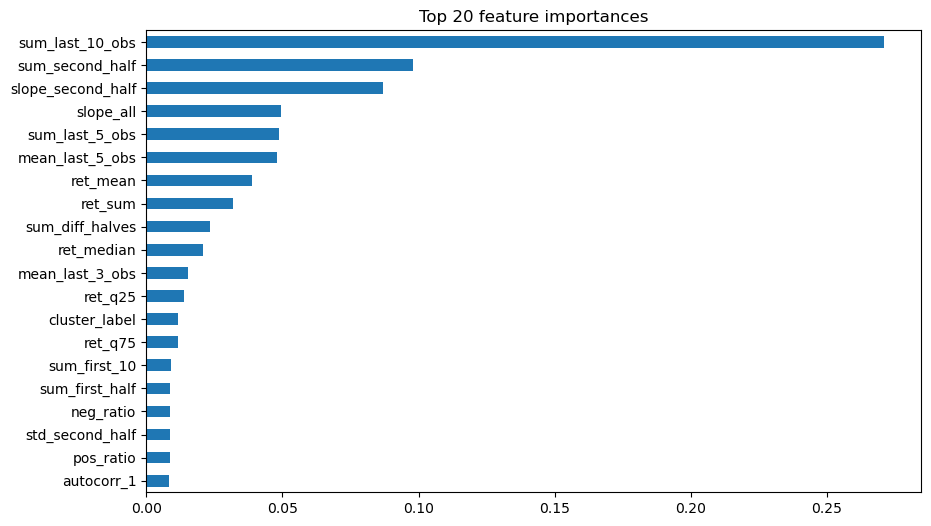

In [27]:
best_model.fit(X_model, y)

if hasattr(best_model.named_steps["model"], "feature_importances_"):
    importances = pd.Series(
        best_model.named_steps["model"].feature_importances_,
        index=X_model.columns
    ).sort_values(ascending=False)
    
    display(importances.head(20))
    
    plt.figure(figsize=(10, 6))
    importances.head(20).sort_values().plot(kind="barh")
    plt.title("Top 20 feature importances")
    plt.show()

### Importance des variables

L'analyse de l'importance des variables met en évidence les features les plus influentes dans la prédiction de la variable cible.

Parmi les variables les plus importantes, on retrouve notamment :

$
sum\_last\_10\_obs
$

$
sum\_second\_half
$

$
slope\_second\_half
$

$
sum\_last\_5\_obs
$

$
mean\_last\_5\_obs
$

Ces variables décrivent principalement la dynamique des rendements **dans la seconde moitié de la séance de trading**.

Ce résultat est économiquement cohérent : les informations les plus récentes observées sur le marché ont généralement un pouvoir prédictif plus élevé concernant la direction finale des prix.

sum_last_10_obs      0.257119
slope_second_half    0.055710
sum_second_half      0.044481
slope_all            0.025284
sum_last_5_obs       0.015857
ret_mean             0.015361
mean_last_5_obs      0.014831
ret_sum              0.014082
sum_diff_halves      0.010490
cluster_label        0.009082
ret_median           0.008550
std_second_half      0.008501
ret_q75              0.008059
autocorr_1           0.007390
ret_q25              0.007291
mean_last_3_obs      0.007172
ret_abs_sum          0.005591
n_big_neg            0.005102
ret_max              0.004970
n_big_pos            0.004953
dtype: float64

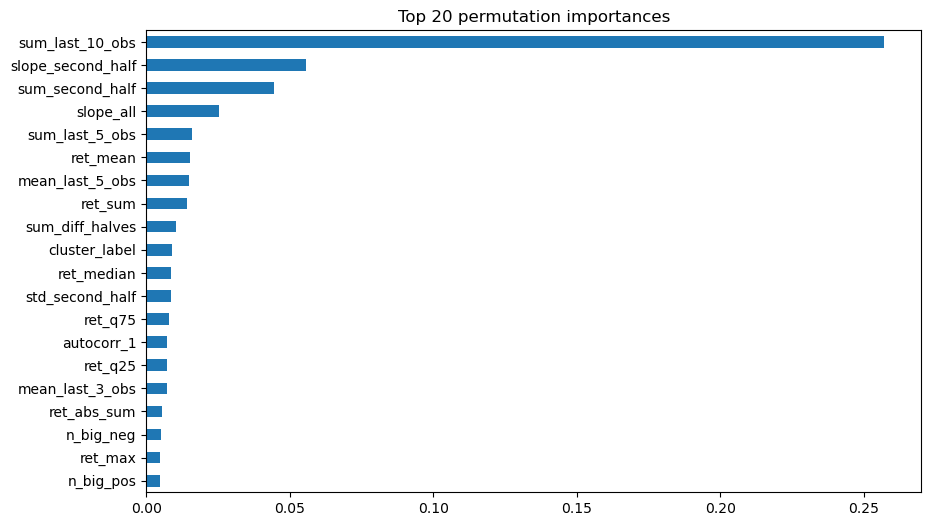

In [28]:
perm = permutation_importance(
    best_model,
    X_model,
    y,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="f1_macro"
)

perm_importances = pd.Series(perm.importances_mean, index=X_model.columns).sort_values(ascending=False)

display(perm_importances.head(20))

plt.figure(figsize=(10, 6))
perm_importances.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 permutation importances")
plt.show()

### Importance par permutation

Une analyse supplémentaire de l’importance des variables a été réalisée à l’aide de la méthode de permutation importance.

Les résultats confirment que les variables liées aux rendements observés dans la **seconde moitié de la journée** sont les plus déterminantes pour la prédiction.

Cette cohérence entre différentes méthodes d’interprétation renforce la robustesse de l'analyse et confirme que les variables décrivant la dynamique récente du marché contiennent une information prédictive importante.

## 12. Final model and prediction
- Entraînement sur tout le train
- Prédiction sur le test
- Création du fichier de soumission

In [29]:
best_model.fit(X_model, y)
test_pred = best_model.predict(X_model_test)

In [30]:
submission = pd.DataFrame({
    "ID": id_test,
    "reod": test_pred
})

submission.to_csv("submission.csv", index=False)
submission.head()

,ID,reod
0,1,2
1,2,1
2,3,2
3,4,2
4,5,1


In [31]:
submission["reod"].value_counts()

reod
1    1777
2     374
0     349
Name: count, dtype: int64

| classe | interprétation                   |
| ------ | -------------------------------- |
| 0      | titres qui devraient **baisser** |
| 1      | titres **stables**               |
| 2      | titres qui devraient **monter**  |


In [34]:
submission[submission["reod"] == -1]
submission[submission["reod"] == 0]
submission[submission["reod"] == 1]
submission["reod"].value_counts(normalize=True)

reod
1    0.7108
2    0.1496
0    0.1396
Name: proportion, dtype: float64

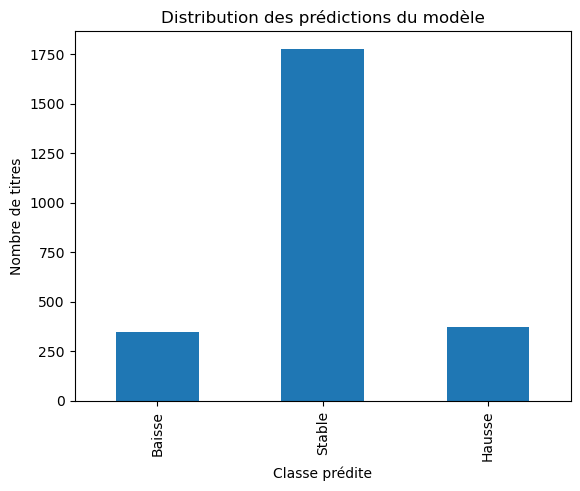

Exception ignored in: <function ResourceTracker.__del__ at 0x10dd05b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


In [35]:
submission["reod"].value_counts().sort_index().plot(kind="bar")

plt.xticks([0, 1, 2], ["Baisse (-1)", "Stable (0)", "Hausse (+1)"])
plt.title("Distribution des prédictions du modèle")
plt.xlabel("Classe prédite")
plt.ylabel("Nombre d'observations")
plt.show()

### Analyse des prédictions du modèle

L'analyse des prédictions du modèle permet d'observer la répartition des titres selon la direction anticipée du prix.

Les valeurs de la variable `reod` correspondent à :

- 0 : prédiction de baisse du prix
- 1 : variation faible ou stable
- 2 : prédiction de hausse du prix

La majorité des observations est généralement classée dans la catégorie centrale, ce qui est cohérent avec la structure observée dans les données d'entraînement où les variations modérées sont les plus fréquentes.

Les titres classés dans les catégories 0 et 2 correspondent aux mouvements de marché plus importants anticipés par le modèle.

## 13. Conclusion
- Comparaison des modèles
- Interprétation économique / statistique
- Limites
- Pistes d'amélioration

## Conclusion

L’objectif de ce projet était de prédire la direction du prix d’une action durant les deux dernières heures de trading en utilisant les rendements observés plus tôt dans la journée.

Les résultats obtenus montrent que les rendements intraday contiennent une information prédictive significative sur le comportement final du marché. Les modèles entraînés atteignent une accuracy d’environ 0.90, ce qui indique que les variables construites permettent de capturer une partie importante de la dynamique intraday des prix.

Parmi les modèles testés, la régression logistique obtient les meilleures performances, suivie de près par les méthodes d’ensemble telles que Random Forest et Gradient Boosting. Cela suggère que la relation entre les variables explicatives et la variable cible est relativement simple et peut être capturée efficacement par des modèles relativement peu complexes.

L’analyse de l’importance des variables montre que les caractéristiques décrivant la seconde moitié de la séance de trading sont les plus informatives pour prédire la direction finale du prix. Ce résultat est cohérent avec l’intuition économique selon laquelle les mouvements de marché les plus récents contiennent généralement davantage d’information sur l’évolution future des prix.

Ce travail met ainsi en évidence l’intérêt de l’utilisation de techniques de machine learning pour exploiter les données intraday et détecter des signaux prédictifs dans les séries financières.